In [1]:
# libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import json


import seaborn as sns
from matplotlib.lines import Line2D


from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

from sklearn.metrics import mean_absolute_error



In [2]:
labels = [# 'human',
          'gpt_5.1',
          'gpt_5.4',
          'gpt_5.4_mini',
          'gpt_5.4_nano',
          'Llama_3.3_70B_Instruct',
          'Gemma_4_31B',
          'Qwen3.5_27B',
          'Qwen3.5_9B',
          ]

In [3]:
def get_terminal_node_probability(take_prob: np.ndarray, tol = 1.0e-4) -> np.ndarray:
    assert len(take_prob)==6 and (take_prob > -tol).all() and (take_prob < 1.+tol).all()
    terminal_node_probability = np.ones(len(take_prob)+1, dtype=float)
    
    terminal_node_probability[0]= take_prob[0]
    for i in range(1, len(take_prob)):
        for j in range(i):
            terminal_node_probability[i] *= (1-take_prob[j])
        terminal_node_probability[i] *= take_prob[i]
    terminal_node_probability[-1] = np.prod(1-take_prob)
    
    assert np.isclose(terminal_node_probability.sum(), 1.)
    return terminal_node_probability
    

In [4]:
# parameters of file
task = 'cg'
values = [0, 140]
v = 1
n = 3

framed = False

In [5]:
project_dir = os.path.abspath("..")

In [6]:
support = np.arange(1,7)
take = 'X'
refs = {0: np.array([0.19512195, 0.25609756, 0.26219512, 0.16463415, 0.07317073, 0.04268293, 0.00609756], dtype=float),
        140: np.array([0.22222222, 0.20061728, 0.10493827, 0.09259259, 0.10185185, 0.0308642 , 0.24691358], dtype=float)
        }


refs_take_prob = {key: [ref[i]/ref[i:].sum() for i in range(len(ref)-1)] for key, ref in refs.items()}
print(refs_take_prob)

{0: [np.float64(0.19512195000000002), np.float64(0.3181818164876033), np.float64(0.4777777723111112), np.float64(0.5744680895608872), np.float64(0.5999999836000001), np.float64(0.8750000256249988)], 140: [np.float64(0.22222222222222224), np.float64(0.2579365054365079), np.float64(0.18181818024307242), np.float64(0.19607842680507495), np.float64(0.26829267778703153), np.float64(0.11111111911111106)]}


In [7]:


distances_baseline = {}

for value in values:
    for blinded in ['blinded', 'unblinded']:
        distances = {}
        for label in labels:
        
            n=3
            if label == 'Qwen3.5_27B':
                n=9
        
            file_name = f'{label}-cg-{value}-v{v}-n{n}-{blinded}-seq.json'
            
            path_to_file = os.path.join(project_dir, 'output', file_name)
            with open(path_to_file, encoding='utf-8') as f:
                 data = json.load(f)
                
            take_probability = np.zeros(len(support), dtype=float)
            # std_take_probability = np.zeros(len(support), dtype=float)
            
            for role in ['A', 'B']:
                nan_count = 0
                count = 0
                for k, sample_dict_list in data[f'role{role}'].items():
                    # print(k, '\n')
                    mean_take_values = []
                    # std_take_values = []
                    for sample_dict in sample_dict_list:
                        # print(sample_dict)
                        take_values = []
                        for sample, sample_values in sample_dict.items():
                            # print(sample, sample_values)
                            count += 1
                            if sample_values['X'] is None and sample_values['Y'] is None:
                                print('both values are nans so we set them to 0.5')
                                nan_count += 2
                                sample_values['X'] = .5
                                sample_values['Y'] = .5
                            elif sample_values['X'] is None:
                                # print('X is nan so we set it to 1-Y')
                                nan_count += 1
                                sample_values['X'] = 1 - sample_values['Y']
                            elif sample_values['Y'] is None:
                                # print('Y is nan so we set it to 1-X')
                                nan_count += 1
                                sample_values['Y'] = 1 - sample_values['X']
                                
                            sample_values['X'] =np.clip(sample_values['X'], 0, 1)
                            sample_values['Y'] =np.clip(sample_values['Y'], 0, 1)
                            
                            somma = sample_values['X'] + sample_values['Y']
                            sample_values['X'] /= somma
                            sample_values['Y'] /= somma
                            take_values.append(sample_values[take])
                        mean_take_values.append(np.mean(take_values))
                        # std_take_values.append(np.std(take_values))
                    take_probability[int(k)-1] = np.mean(mean_take_values)
                    # std_take_probability[int(k)-1] = np.mean(std_take_values)
                    
                if nan_count > 0:
                    print(f'there are {nan_count} nans over {2*count} elements')
                    
            terminal_node_probability = get_terminal_node_probability(take_probability)
            # dist = jensenshannon(refs[value], terminal_node_probability)
            # dist = wasserstein_distance(np.arange(1,8), np.arange(1,8), 
            #                             u_weights=refs[value], v_weights=terminal_node_probability)
            
            dist = mean_absolute_error(refs_take_prob[value],take_probability)
            
            distances[label] = float(dist)
            
        distances_baseline[f'{value}-{blinded}'] = distances
            

        

there are 27 nans over 54 elements
there are 18 nans over 54 elements
there are 2 nans over 54 elements
there are 22 nans over 54 elements
there are 12 nans over 54 elements
there are 27 nans over 54 elements
there are 18 nans over 54 elements
there are 27 nans over 54 elements
there are 18 nans over 54 elements
there are 27 nans over 54 elements
there are 18 nans over 54 elements
there are 9 nans over 54 elements
there are 22 nans over 54 elements
there are 9 nans over 54 elements
there are 27 nans over 54 elements
there are 16 nans over 54 elements
there are 7 nans over 54 elements
there are 24 nans over 54 elements
there are 18 nans over 54 elements


In [8]:
for value in values:
    for blinded in ['blinded', 'unblinded']:
        print(f'{value}-{blinded}')
        print(distances_baseline[f'{value}-{blinded}'])

0-blinded
{'gpt_5.1': 0.35873834203731025, 'gpt_5.4': 0.37009137573538603, 'gpt_5.4_mini': 0.2314606257883486, 'gpt_5.4_nano': 0.4346301491587397, 'Llama_3.3_70B_Instruct': 0.3398669198138469, 'Gemma_4_31B': 0.3860397018551325, 'Qwen3.5_27B': 0.1637269966940371, 'Qwen3.5_9B': 0.3316008618335065}
0-unblinded
{'gpt_5.1': 0.2782666989767854, 'gpt_5.4': 0.2910081267107782, 'gpt_5.4_mini': 0.19900912412677774, 'gpt_5.4_nano': 0.4455890718857543, 'Llama_3.3_70B_Instruct': 0.28262721791686357, 'Gemma_4_31B': 0.3901697938482096, 'Qwen3.5_27B': 0.20895831736165218, 'Qwen3.5_9B': 0.3635534541995589}
140-blinded
{'gpt_5.1': 0.2059442439464302, 'gpt_5.4': 0.5958134723511295, 'gpt_5.4_mini': 0.13776338319148754, 'gpt_5.4_nano': 0.7141745768483613, 'Llama_3.3_70B_Instruct': 0.38805471268819286, 'Gemma_4_31B': 0.6989555431925148, 'Qwen3.5_27B': 0.3028151905629328, 'Qwen3.5_9B': 0.5860427537637425}
140-unblinded
{'gpt_5.1': 0.20584113906996093, 'gpt_5.4': 0.5687131204860357, 'gpt_5.4_mini': 0.22597990

In [9]:
path_to_human_svo_profiles = os.path.join(project_dir, 'data', 'human_svo_profiles_beta.csv')
human_svo_profiles = pd.read_csv(path_to_human_svo_profiles)
human_svo_profiles['svo'] = human_svo_profiles['svo'].astype(int)
human_svo_profiles['frequency'] = human_svo_profiles['count'] / human_svo_profiles['count'].sum()


assert np.isclose(human_svo_profiles['frequency'].sum(), 1.)

In [10]:
distances_framing = {}

for value in values:
    for blinded in ['blinded', 'unblinded']:
        distances = {}
        for label in labels:
        
            n=3
            # if label == 'Qwen3.5_27B':
            #     n=9
        
            file_name = f'{label}-cg-{value}-v{v}-n{n}-{blinded}-framed-seq-explicit.json'
            
            path_to_file = os.path.join(project_dir, 'output', file_name)
            with open(path_to_file, encoding='utf-8') as f:
                 data = json.load(f)
                
            take_results = {}
            for svo, output in data.items():
            
                take_probability = np.zeros(len(support), dtype=float)
                # std_take_probability = np.zeros(len(support), dtype=float)
            
                for role in ['A', 'B']:
                    for k, sample_dict_list in output[f'role{role}'].items():
                        # print(k, '\n')
                        mean_take_values = []
                        # std_take_values = []
                        for list_idx, sample_dict in enumerate(sample_dict_list):
                            # print(sample_dict)
                            take_values = []
                            for sample, sample_values in sample_dict.items():
                                # print(sample, sample_values)
                                if sample_values['X'] is None and sample_values['Y'] is None:
                                    print(f'both values are nans so we skip them, {label}, {value}, {blinded}')
                                    # sample_values['X'] = .5
                                    # sample_values['Y'] = .5
                                    # print(output[f'role{role}'][k][list_idx][sample])
                                    # print('DELETE')
                                    # del output[f'role{role}'][k][list_idx][sample]
                                else:
                                    if sample_values['X'] is None:
                                        # print('X is nan so we set it to 1-Y')
                                        sample_values['X'] = 1 - sample_values['Y']
                                    elif sample_values['Y'] is None:
                                        # print('Y is nan so we set it to 1-X')
                                        sample_values['Y'] = 1 - sample_values['X']
                                        
                                    sample_values['X'] =np.clip(sample_values['X'], 0, 1)
                                    sample_values['Y'] =np.clip(sample_values['Y'], 0, 1)
                                    
                                    somma = sample_values['X'] + sample_values['Y']
                                    sample_values['X'] /= somma
                                    sample_values['Y'] /= somma
                                    take_values.append(sample_values[take])
                            mean_take_values.append(np.mean(take_values))
                            # std_take_values.append(np.std(take_values))
                        take_probability[int(k)-1] = np.mean(mean_take_values)
                        # std_take_probability[int(k)-1] = np.mean(std_take_values)
                    
                take_results[int(svo)] = take_probability
                        
            results_df = pd.DataFrame(take_results).T
            results_df.index.name = "svo"
            
            joined = pd.merge(human_svo_profiles[['svo', 'frequency']], results_df, on="svo")
            
            take_probs_framing = np.full(6, -1., dtype=float)
            if len(joined)>0:
                for ii in range(6):
                    take_probs_framing[ii] = (joined['frequency']*joined[ii]).sum()

            terminal_node_probability = get_terminal_node_probability(take_probs_framing)
            # dist = jensenshannon(refs[value], terminal_node_probability)
            # dist = wasserstein_distance(np.arange(1,8), np.arange(1,8), 
            # u_weights=refs[value], v_weights=terminal_node_probability)
            
            
            dist = mean_absolute_error(refs_take_prob[value], take_probs_framing)
            
            
            
            
            if value == 0 and blinded == 'unblinded' and label == 'Qwen3.5_27B':
                # optimal_zero = terminal_node_probability
                optimal_take_prob_zero = take_probs_framing
                min_dist_zero = dist
                
                optimal_zero = np.zeros(7, dtype=float)
                for svo1, row1 in joined.iterrows():
                    for svo2, row2 in joined.iterrows():
                        p = row1['frequency']*row2['frequency']
                        terminal_node_prob1 = get_terminal_node_probability(np.array([row1[0], row2[1], row1[2], row2[3], row1[4], row2[5]]))
                        terminal_node_prob2 = get_terminal_node_probability(np.array([row2[0], row1[1], row2[2], row1[3], row2[4], row1[5]]))
                        optimal_zero += p * .5 * (terminal_node_prob1 + terminal_node_prob2)
                        
                    
            elif value == 140 and blinded == 'blinded' and label == 'gpt_5.4_mini':
                # optimal_fair = terminal_node_probability
                optimal_take_prob_fair = take_probs_framing
                min_dist_fair = dist
                
                optimal_fair = np.zeros(7, dtype=float)
                for svo1, row1 in joined.iterrows():
                    for svo2, row2 in joined.iterrows():
                        p = row1['frequency']*row2['frequency']
                        terminal_node_prob1 = get_terminal_node_probability(np.array([row1[0], row2[1], row1[2], row2[3], row1[4], row2[5]]))
                        terminal_node_prob2 = get_terminal_node_probability(np.array([row2[0], row1[1], row2[2], row1[3], row2[4], row1[5]]))
                        optimal_fair += p * .5 * (terminal_node_prob1 + terminal_node_prob2)
            
            distances[label] = float(dist)
            
        distances_framing[f'{value}-{blinded}'] = distances
        
        
terminal_node_random = get_terminal_node_probability(np.full(6, .5))
        

both values are nans so we skip them, Qwen3.5_9B, 0, blinded
both values are nans so we skip them, Qwen3.5_9B, 140, blinded
both values are nans so we skip them, Qwen3.5_9B, 140, blinded


In [11]:
for value in values:
    for blinded in ['blinded', 'unblinded']:
        print(f'{value}-{blinded}')
        print(distances_framing[f'{value}-{blinded}'])

0-blinded
{'gpt_5.1': 0.2963159868226351, 'gpt_5.4': 0.2752961906052592, 'gpt_5.4_mini': 0.15356280679487996, 'gpt_5.4_nano': 0.29490541983709245, 'Llama_3.3_70B_Instruct': 0.25747152659856454, 'Gemma_4_31B': 0.269424065433757, 'Qwen3.5_27B': 0.10059467778874354, 'Qwen3.5_9B': 0.1947129059153636}
0-unblinded
{'gpt_5.1': 0.27657228625463975, 'gpt_5.4': 0.30240247518462793, 'gpt_5.4_mini': 0.19447438592723257, 'gpt_5.4_nano': 0.3439627853746124, 'Llama_3.3_70B_Instruct': 0.24336646819882615, 'Gemma_4_31B': 0.28114118684277406, 'Qwen3.5_27B': 0.08671794299142999, 'Qwen3.5_9B': 0.21905480037787597}
140-blinded
{'gpt_5.1': 0.20074430136024232, 'gpt_5.4': 0.15399368435912164, 'gpt_5.4_mini': 0.09850402863676588, 'gpt_5.4_nano': 0.5742065559585884, 'Llama_3.3_70B_Instruct': 0.18664640289830248, 'Gemma_4_31B': 0.4624030810157815, 'Qwen3.5_27B': 0.17461307612692123, 'Qwen3.5_9B': 0.41483082957166806}
140-unblinded
{'gpt_5.1': 0.20368116726833563, 'gpt_5.4': 0.1745463274581035, 'gpt_5.4_mini': 0

In [ ]:
# Models to display on the y-axis
models = labels
y = np.arange(len(models))

treatments = {0: 'zero-end CG', 140: 'fair-end CG'}

# Small vertical offset so X and Y do not overlap
offset = 0.12

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    gridspec_kw={"height_ratios": [2, 1],
                 "hspace": 0.4,
                 "wspace": 0.1},
    # sharex=True,
    # sharey=True
)

for ax, group in zip(axes[0,:], values):
    differences = []
    ratios=[]
    fr = []
    bl = []
    for suffix, dy, color in [
        ('blinded', -offset, 'tab:green'),
        ('unblinded', +offset, 'tab:purple'),
    ]:
        key = f'{group}-{suffix}'

        # for i, model in enumerate(models):
        #     x1 = distances_baseline[key][model]
        #     x2 = distances_framing[key][model]
        # 
        #     # Horizontal line connecting dict1 and dict2 values
        #     ax.plot(
        #         [x1, x2],
        #         [y[i] + dy, y[i] + dy],
        #         color=color,
        #         linewidth=2,
        #         # marker='o',
        #         label=suffix if i == 0 else None,
        #     )
        
        for i, model in enumerate(models):
            x1 = distances_baseline[key][model]
            x2 = distances_framing[key][model]
            differences.append(x1-x2)
            ratios.append(x2/x1)
            bl.append(x1)
            fr.append(x2)

            ypos = y[i] + dy
            
            

            # Arrow from dict1 value to dict2 value
            ax.annotate(
                '',
                xy=(x2, ypos),       # arrow head: dict2
                xytext=(x1, ypos),  # arrow start: dict1
                arrowprops=dict(
                    arrowstyle='->',
                    color=color,
                    lw=2,
                    mutation_scale=10
                )
            )
            
            # Optional: distinguish endpoints corresponding to dict1/dict2
            ax.scatter(x1, ypos, color=color, marker='o')
            ax.scatter(x2, ypos, color=color, marker='*')

        # Dummy handle for legend
        ax.plot([], [], color=color, lw=2, label=suffix)
    
    # distance_random = jensenshannon(refs[group], terminal_node_random)    
    # distance_random = wasserstein_distance(np.arange(1,8), np.arange(1,8), 
    #                            u_weights=refs[group], v_weights=terminal_node_random)
    
    distance_random = mean_absolute_error(refs_take_prob[group],  np.full(6, .5))
    
    ax.scatter(distance_random, len(models), color='tab:red', marker='v' )
    ax.axvline(distance_random, color='tab:red', linestyle=':', alpha=0.5)
    ax.set_title(treatments[group], fontsize=20, fontweight='bold')
    ax.set_xlabel('MAE between LLM output and human reference', fontsize=15,)
    ax.grid(axis='x', alpha=0.5)
    ax.set_xlim(0., 1.)
    # ax.set_xlim(0., 3.5)
    ax.set_xticks(np.linspace(0., 1., 6))
    ax.set_xticklabels(np.round(np.linspace(0., 1., 6), 1), fontsize=15,)
    
    # print(differences)
    # print(np.mean(differences))
    # print(np.std(differences))
    
    print(np.mean(ratios)-1)
    print(np.std(ratios))
    # print(fr)
    # print(np.mean(fr))
    # print(np.std(fr))
    # print(np.mean(bl))
    # print(np.std(bl))
    
axes[0,0].set_yticks(np.arange(len(y)+1))
axes[0,0].set_yticklabels(models+['random'], fontsize=15,)

axes[0,1].set_yticks(np.arange(len(y)+1))
axes[0,1].set_yticklabels((len(y)+1) * [''])

axes[0,0].legend(title='prompt type',fontsize=15,title_fontsize=15, handlelength=1.)

# axes[0].set_ylabel('models')


optimal = {0: optimal_zero, 140: optimal_fair}

ls = ['human reference', 'optimal model']
titles = [f'{models[-2]} (min MAE: {np.round(min_dist_zero,2)})', f'{models[2]} (min MAE: {np.round(min_dist_fair,2)})']


width = 0.4


clrs = ['tab:purple', 'tab:green']
for v, value in enumerate(values):
    axes[1,v].bar(np.arange(1,8)- width/2, refs[value], color='tab:blue',width=width, label=ls[0])
    axes[1, v].bar(np.arange(1,8)+ width/2, optimal[value], color=clrs[v], width=width,label=ls[1])
    axes[1, v].set_ylim(0, 0.4)
    axes[1, v].set_title(titles[v], fontsize=15,)
    axes[1, v].set_xlabel('terminal node', fontsize=15,)
    axes[1, v].set_xticks(np.arange(1, 8))
    axes[1, v].set_xticklabels(np.arange(1, 8), fontsize=15,)
    axes[1,v].set_yticks(np.linspace(0., 0.4, 5))
    axes[1,v].legend(ls,fontsize=15, handlelength=1.)

axes[1,0].set_yticklabels(np.round(np.linspace(0., 0.4, 5), 1), fontsize=15,) 
axes[1,1].set_yticklabels(5 * [''])
    
    

axes[1,0].set_ylabel('proportion', fontsize=15, rotation=0, labelpad=40)


markers = ['o', '*']
handles = [
Line2D([0], [0], 
   color='black',
   linewidth=0,
    marker=markers[n],
   label=name,
   )
for n, name in enumerate(['baseline', 'framing'])
]
other_legend = fig.legend(
    handles=handles,
    # title="",
    bbox_to_anchor=(0.36, 0.77),
    loc="upper left",
    #frameon=False,
    fontsize=15,
    #ncol=2,
    #title_fontsize=15,
    handlelength=1,
)

fig.add_artist(other_legend)


#plt.tight_layout()

name = f'res2-v{v}-n{n}.pdf'
path_to_fig = os.path.join(project_dir, 'figures', name)
plt.savefig(path_to_fig, format='pdf', bbox_inches='tight')

plt.show()

-0.2531062738042561
0.15974727912563022
-0.3610315778038996
0.21049224252549764


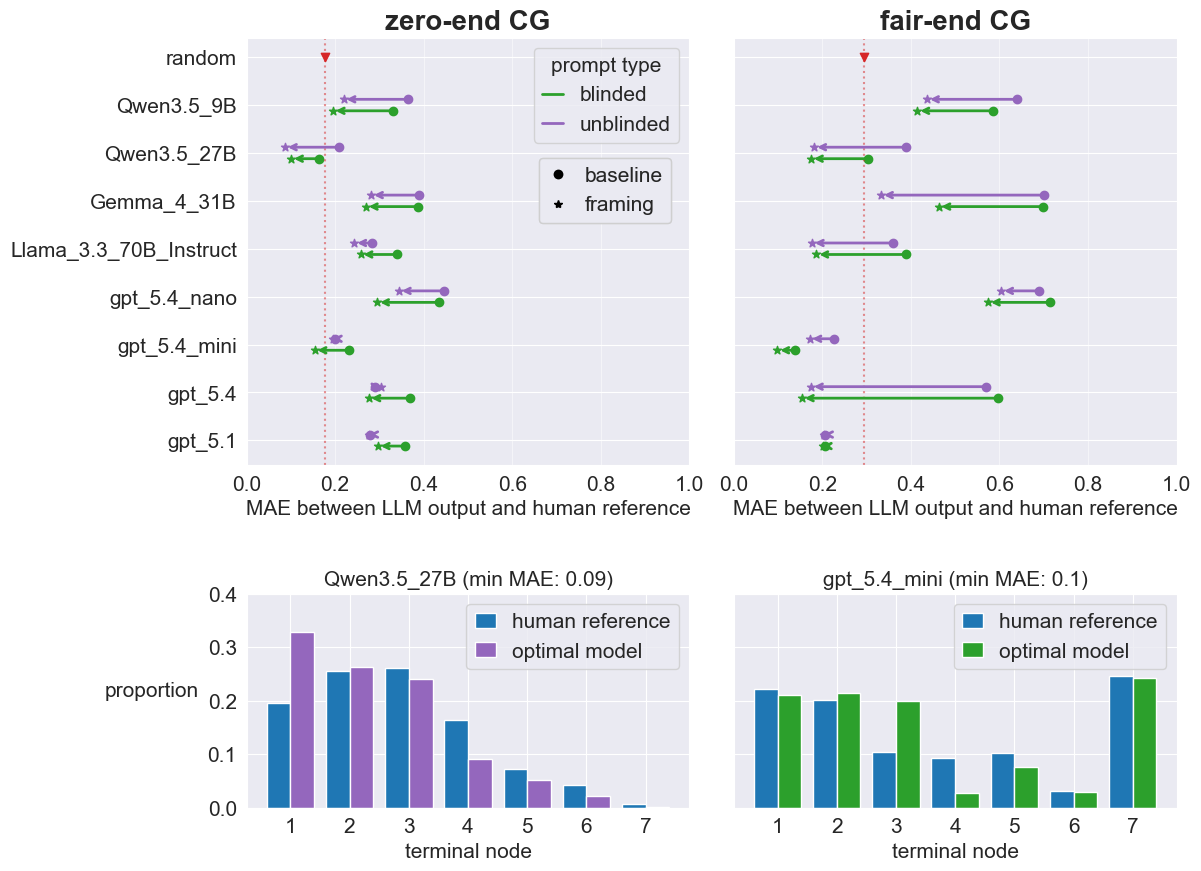

In [12]:
# Models to display on the y-axis
models = labels
y = np.arange(len(models))

treatments = {0: 'zero-end CG', 140: 'fair-end CG'}

# Small vertical offset so X and Y do not overlap
offset = 0.12

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10),
    gridspec_kw={"height_ratios": [2, 1],
                 "hspace": 0.4,
                 "wspace": 0.1},
    # sharex=True,
    # sharey=True
)

for ax, group in zip(axes[0,:], values):
    differences = []
    ratios=[]
    fr = []
    bl = []
    for suffix, dy, color in [
        ('blinded', -offset, 'tab:green'),
        ('unblinded', +offset, 'tab:purple'),
    ]:
        key = f'{group}-{suffix}'

        # for i, model in enumerate(models):
        #     x1 = distances_baseline[key][model]
        #     x2 = distances_framing[key][model]
        # 
        #     # Horizontal line connecting dict1 and dict2 values
        #     ax.plot(
        #         [x1, x2],
        #         [y[i] + dy, y[i] + dy],
        #         color=color,
        #         linewidth=2,
        #         # marker='o',
        #         label=suffix if i == 0 else None,
        #     )
        
        for i, model in enumerate(models):
            x1 = distances_baseline[key][model]
            x2 = distances_framing[key][model]
            differences.append(x1-x2)
            ratios.append(x2/x1)
            bl.append(x1)
            fr.append(x2)

            ypos = y[i] + dy
            
            

            # Arrow from dict1 value to dict2 value
            ax.annotate(
                '',
                xy=(x2, ypos),       # arrow head: dict2
                xytext=(x1, ypos),  # arrow start: dict1
                arrowprops=dict(
                    arrowstyle='->',
                    color=color,
                    lw=2,
                    mutation_scale=10
                )
            )
            
            # Optional: distinguish endpoints corresponding to dict1/dict2
            ax.scatter(x1, ypos, color=color, marker='o')
            ax.scatter(x2, ypos, color=color, marker='*')

        # Dummy handle for legend
        ax.plot([], [], color=color, lw=2, label=suffix)
    
    # distance_random = jensenshannon(refs[group], terminal_node_random)    
    # distance_random = wasserstein_distance(np.arange(1,8), np.arange(1,8), 
    #                            u_weights=refs[group], v_weights=terminal_node_random)
    
    distance_random = mean_absolute_error(refs_take_prob[group],  np.full(6, .5))
    
    ax.scatter(distance_random, len(models), color='tab:red', marker='v' )
    ax.axvline(distance_random, color='tab:red', linestyle=':', alpha=0.5)
    ax.set_title(treatments[group], fontsize=20, fontweight='bold')
    ax.set_xlabel('MAE between LLM output and human reference', fontsize=15,)
    ax.grid(axis='x', alpha=0.5)
    ax.set_xlim(0., 1.)
    # ax.set_xlim(0., 3.5)
    ax.set_xticks(np.linspace(0., 1., 6))
    ax.set_xticklabels(np.round(np.linspace(0., 1., 6), 1), fontsize=15,)
    
    # print(differences)
    # print(np.mean(differences))
    # print(np.std(differences))
    
    print(np.mean(ratios)-1)
    print(np.std(ratios))
    # print(fr)
    # print(np.mean(fr))
    # print(np.std(fr))
    # print(np.mean(bl))
    # print(np.std(bl))
    
axes[0,0].set_yticks(np.arange(len(y)+1))
axes[0,0].set_yticklabels(models+['random'], fontsize=15,)

axes[0,1].set_yticks(np.arange(len(y)+1))
axes[0,1].set_yticklabels((len(y)+1) * [''])

axes[0,0].legend(title='prompt type',fontsize=15,title_fontsize=15, handlelength=1.)

# axes[0].set_ylabel('models')


optimal = {0: optimal_zero, 140: optimal_fair}

ls = ['human reference', 'optimal model']
titles = [f'{models[-2]} (min MAE: {np.round(min_dist_zero,2)})', f'{models[2]} (min MAE: {np.round(min_dist_fair,2)})']


width = 0.4


clrs = ['tab:purple', 'tab:green']
for v, value in enumerate(values):
    axes[1,v].bar(np.arange(1,8)- width/2, refs[value], color='tab:blue',width=width, label=ls[0])
    axes[1, v].bar(np.arange(1,8)+ width/2, optimal[value], color=clrs[v], width=width,label=ls[1])
    axes[1, v].set_ylim(0, 0.4)
    axes[1, v].set_title(titles[v], fontsize=15,)
    axes[1, v].set_xlabel('terminal node', fontsize=15,)
    axes[1, v].set_xticks(np.arange(1, 8))
    axes[1, v].set_xticklabels(np.arange(1, 8), fontsize=15,)
    axes[1,v].set_yticks(np.linspace(0., 0.4, 5))
    axes[1,v].legend(ls,fontsize=15, handlelength=1.)

axes[1,0].set_yticklabels(np.round(np.linspace(0., 0.4, 5), 1), fontsize=15,) 
axes[1,1].set_yticklabels(5 * [''])
    
    

axes[1,0].set_ylabel('proportion', fontsize=15, rotation=0, labelpad=40)


markers = ['o', '*']
handles = [
Line2D([0], [0], 
   color='black',
   linewidth=0,
    marker=markers[n],
   label=name,
   )
for n, name in enumerate(['baseline', 'framing'])
]
other_legend = fig.legend(
    handles=handles,
    # title="",
    bbox_to_anchor=(0.36, 0.77),
    loc="upper left",
    #frameon=False,
    fontsize=15,
    #ncol=2,
    #title_fontsize=15,
    handlelength=1,
)

fig.add_artist(other_legend)


#plt.tight_layout()

name = f'res2-v{v}-n{n}.pdf'
path_to_fig = os.path.join(project_dir, 'figures', name)
plt.savefig(path_to_fig, format='pdf', bbox_inches='tight')

plt.show()

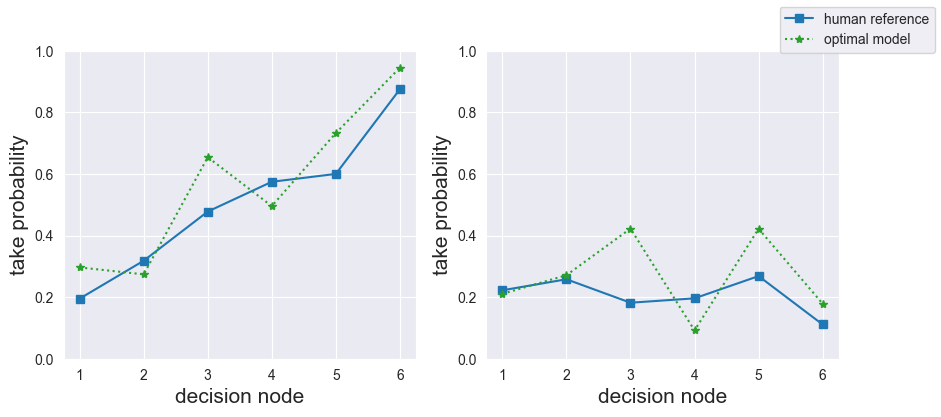

In [37]:

nodes = np.arange(1,7)


optimal_take = {0: optimal_take_prob_zero, 140: optimal_take_prob_fair}

fig, ax = plt.subplots(1,2, figsize=(10,4))

for v, value in enumerate(values):
    ax[v].plot(nodes, refs_take_prob[value], color='tab:blue', marker='s', linestyle='-', label=ls[0])
    ax[v].plot(nodes, optimal_take[value], color='tab:green', marker='*', linestyle=':', label=ls[1])
    ax[v].set_ylim(0., 1.)
    ax[v].set_xlabel('decision node', fontsize=15,)
    ax[v].set_ylabel('take probability', fontsize=15,)
    
fig.legend(ls)
plt.show()